# Bike-lane surface analysis

This notebook explores smartphone sensor recordings to distinguish smooth and bumpy bike lanes. It covers data checks, preprocessing, feature extraction, and model experiments.

## 1. Imports

In [398]:
import pandas as pd
import numpy as np      
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import skfuzzy as fuzz
from scipy.linalg import norm
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import linkage, cut_tree
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from pyfume import *
from scipy.stats import multivariate_normal



## 2. Explore example recordings

Inspect example accelerometer recordings and compare the three sensor signals before preprocessing.

In [399]:
#Acceleration of a bumpy road
df = pd.read_csv(
    "../Machine_Learning_for_rides/data/P03_B01/Accelerometer.csv"
                 )

#Dataframe information

df.head()
df.shape
df.columns  #column names
df.info()   #type of each column, number of non-null values


<class 'pandas.DataFrame'>
RangeIndex: 12449 entries, 0 to 12448
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             12449 non-null  int64  
 1   seconds_elapsed  12449 non-null  float64
 2   z                12449 non-null  float64
 3   y                12449 non-null  float64
 4   x                12449 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 486.4 KB


In [400]:
#Calculate the minimum and maximum values of the "seconds_elapsed" column

df["seconds_elapsed"].min()
df["seconds_elapsed"].max()
df["seconds_elapsed"]

0          0.061081
1          0.071083
2          0.081085
3          0.091087
4          0.101089
            ...    
12444    124.524637
12445    124.534638
12446    124.544640
12447    124.554642
12448    124.564644
Name: seconds_elapsed, Length: 12449, dtype: float64

### Missing values

Check the example recording for missing measurements.

In [401]:
df.isnull()

,time,seconds_elapsed,z,y,x
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
12444,False,False,False,False,False
12445,False,False,False,False,False
12446,False,False,False,False,False
12447,False,False,False,False,False


In [402]:
df.isnull().sum()

time               0
seconds_elapsed    0
z                  0
y                  0
x                  0
dtype: int64

In [403]:
#Basic Statistics
df.describe() 



,time,seconds_elapsed,z,y,x
count,1.244900e+04,12449.000000,12449.000000,12449.000000,12449.000000
mean,1.789022e+18,62.311858,0.003781,-0.108560,0.046537
std,3.594442e+10,35.944419,1.925489,2.670446,1.568168
min,1.789022e+18,0.061081,-12.795789,-19.433005,-14.150093
25%,1.789022e+18,31.187237,-1.047587,-1.410569,-0.818246
50%,1.789022e+18,62.311966,-0.114168,0.082983,0.042481
75%,1.789022e+18,93.436267,0.976360,1.399188,0.897919
max,1.789022e+18,124.564644,33.843324,9.172444,22.304848


In [404]:
df = pd.read_csv(
    "../Machine_Learning_for_rides/data/P03_S02/Accelerometer.csv"
                 )
df.describe() 

,time,seconds_elapsed,z,y,x
count,7.911000e+03,7911.000000,7911.000000,7911.000000,7911.000000
mean,1.789031e+18,39.583527,0.103093,-0.151797,0.036580
std,2.284758e+10,22.847582,0.462765,0.681244,0.526570
min,1.789031e+18,0.017205,-3.458470,-8.998177,-3.260045
25%,1.789031e+18,19.800832,-0.156165,-0.557015,-0.292004
50%,1.789031e+18,39.583809,0.100512,-0.167345,0.043365
75%,1.789031e+18,59.366381,0.369314,0.237830,0.376016
max,1.789031e+18,79.148731,3.746711,10.218142,2.582894


Text(0.5, 0, 'Time (seconds)')

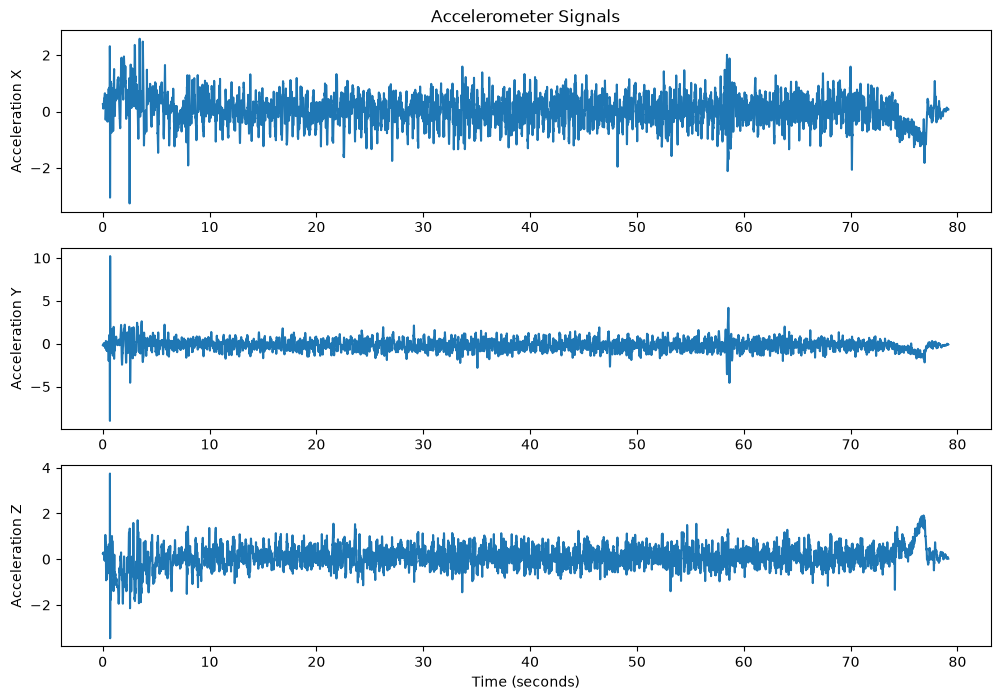

In [405]:
#Plot graph

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(df["seconds_elapsed"], df["x"])
plt.ylabel("Acceleration X")
plt.title("Accelerometer Signals")
plt.subplot(3, 1, 2)
plt.plot(df["seconds_elapsed"], df["y"])
plt.ylabel("Acceleration Y")
plt.subplot(3, 1, 3)
plt.plot(df["seconds_elapsed"], df["z"])
plt.ylabel("Acceleration Z")
plt.xlabel("Time (seconds)")


In [406]:
#Acceleration of a smooth road
df = pd.read_csv(
    "../Machine_Learning_for_rides/data/P03_S02/Accelerometer.csv"
                 )

#Dataframe information

df.head()
df.shape
df.columns  #column names
df.info()   #type of each column, number of non-null values


<class 'pandas.DataFrame'>
RangeIndex: 7911 entries, 0 to 7910
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             7911 non-null   int64  
 1   seconds_elapsed  7911 non-null   float64
 2   z                7911 non-null   float64
 3   y                7911 non-null   float64
 4   x                7911 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 309.2 KB


Text(0.5, 0, 'Time (seconds)')

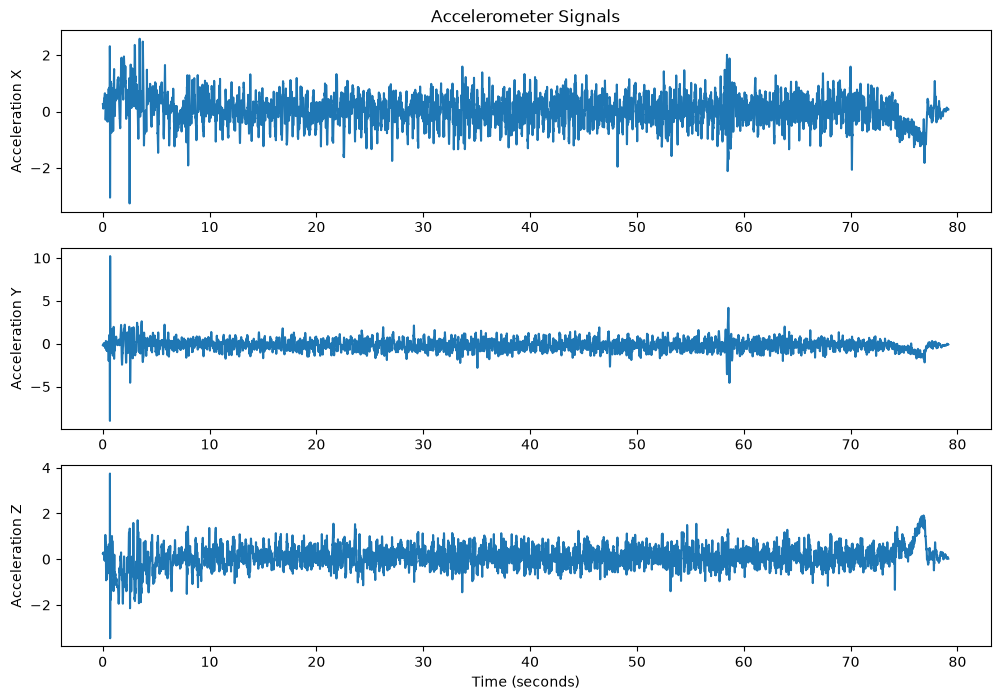

In [407]:
#Plot graph

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(df["seconds_elapsed"], df["x"])
plt.ylabel("Acceleration X")
plt.title("Accelerometer Signals")
plt.subplot(3, 1, 2)
plt.plot(df["seconds_elapsed"], df["y"])
plt.ylabel("Acceleration Y")
plt.subplot(3, 1, 3)
plt.plot(df["seconds_elapsed"], df["z"])
plt.ylabel("Acceleration Z")
plt.xlabel("Time (seconds)")

### Sensor traces

Plot acceleration, angular velocity, and gravity for a sample interval from smooth and bumpy recordings.

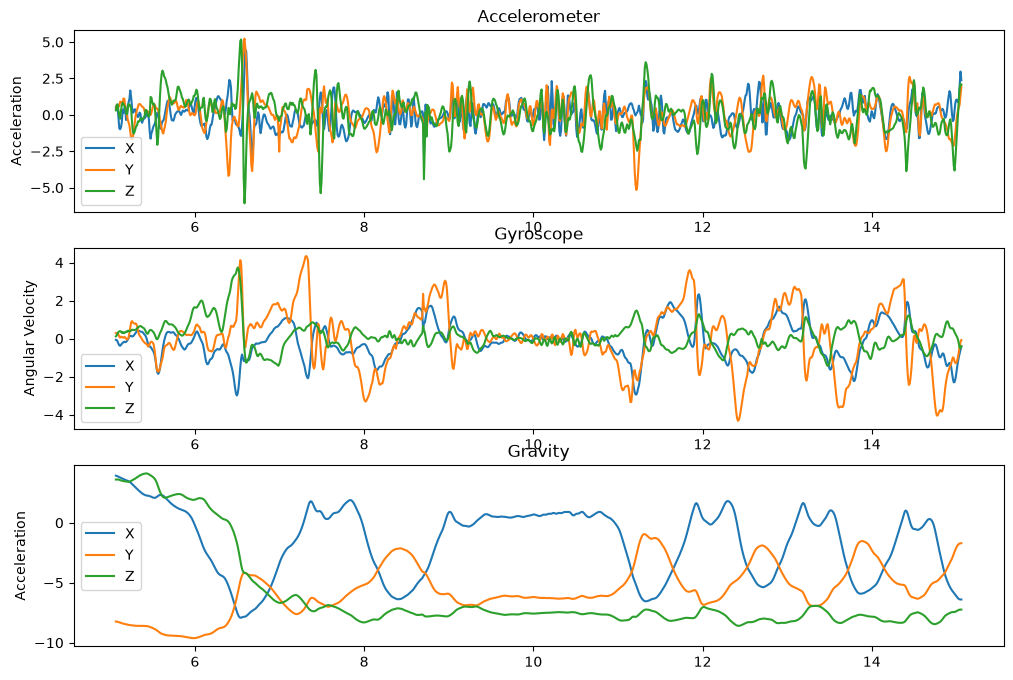

In [408]:
acc = pd.read_csv(
    "../Machine_Learning_for_rides/data/P03_S01/Accelerometer.csv"
                 )
gyr = pd.read_csv('../Machine_Learning_for_rides/data/P03_S01/Gyroscope.csv')
grav = pd.read_csv('../Machine_Learning_for_rides/data/P03_S01/Gravity.csv')

sample_start = 500
sample_number = 1000
sample_end = sample_start + sample_number
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["x"][sample_start:sample_end], label="X")
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["y"][sample_start:sample_end], label="Y")
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["z"][sample_start:sample_end], label="Z")
plt.title("Accelerometer")
plt.ylabel("Acceleration")
plt.legend()
label="X"
label="Y"
label="Z"

plt.subplot(3, 1, 2)
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["x"][sample_start:sample_end], label="X")
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["y"][sample_start:sample_end], label="Y")
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["z"][sample_start:sample_end], label="Z")
plt.title("Gyroscope")
plt.ylabel("Angular Velocity")
plt.legend()
label="X"
label="Y"
label="Z"

plt.subplot(3, 1, 3)
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["x"][sample_start:sample_end], label="X")
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["y"][sample_start:sample_end], label="Y")
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["z"][sample_start:sample_end], label="Z")
plt.title("Gravity")
plt.ylabel("Acceleration")
plt.legend()
label="X"
label="Y"

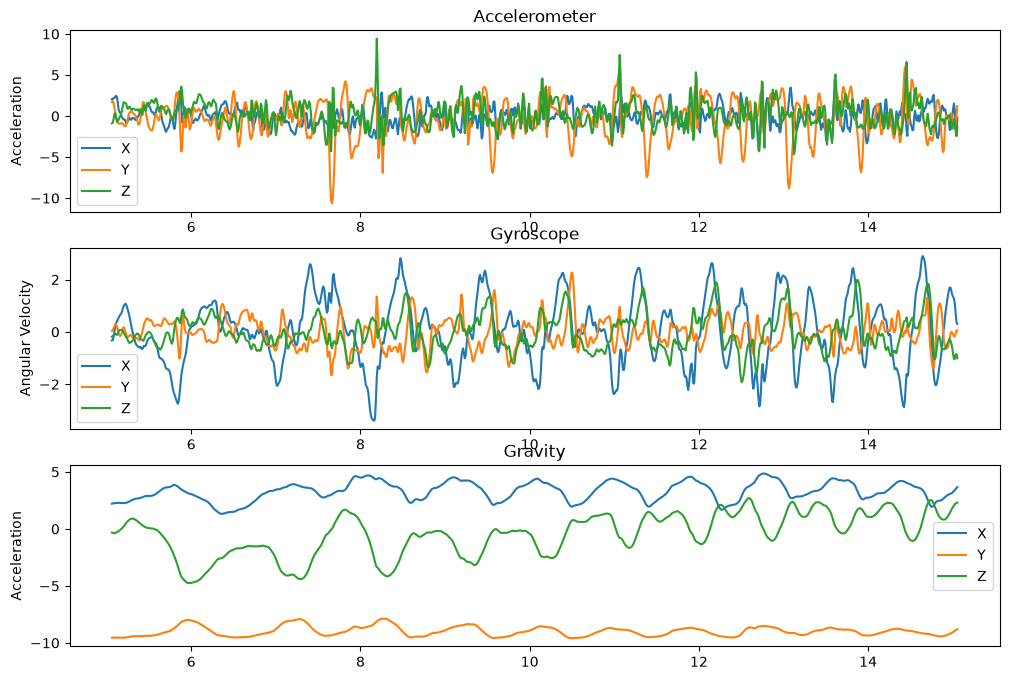

In [409]:
acc = pd.read_csv('../Machine_Learning_for_rides/data/P03_B01/Accelerometer.csv')
gyr = pd.read_csv('../Machine_Learning_for_rides/data/P03_B01/Gyroscope.csv')
grav = pd.read_csv('../Machine_Learning_for_rides/data/P03_B01/Gravity.csv')

sample_start = 500
sample_number = 1000
sample_end = sample_start + sample_number
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["x"][sample_start:sample_end], label="X")
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["y"][sample_start:sample_end], label="Y")
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["z"][sample_start:sample_end], label="Z")
plt.title("Accelerometer")
plt.ylabel("Acceleration")
plt.legend()
label="X"
label="Y"
label="Z"

plt.subplot(3, 1, 2)
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["x"][sample_start:sample_end], label="X")
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["y"][sample_start:sample_end], label="Y")
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["z"][sample_start:sample_end], label="Z")
plt.title("Gyroscope")
plt.ylabel("Angular Velocity")
plt.legend()
label="X"
label="Y"
label="Z"

plt.subplot(3, 1, 3)
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["x"][sample_start:sample_end], label="X")
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["y"][sample_start:sample_end], label="Y")
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["z"][sample_start:sample_end], label="Z")
plt.title("Gravity")
plt.ylabel("Acceleration")
plt.legend()
label="X"
label="Y"

In [410]:
acc.head

<bound method NDFrame.head of                       time  seconds_elapsed         z         y         x
0      1789021725168081200         0.061081  0.365173  0.062416 -0.046858
1      1789021725178082800         0.071083  0.530279  0.035254  0.085074
2      1789021725188085000         0.081085  0.599253  0.100425  0.282690
3      1789021725198087000         0.091087  0.577153  0.158273  0.387016
4      1789021725208088800         0.101089  0.497761  0.152390  0.408698
...                    ...              ...       ...       ...       ...
12444  1789021849631636700       124.524637 -0.416970  0.124601 -0.095672
12445  1789021849641638100       124.534638 -1.359728  0.131461  0.028284
12446  1789021849651640000       124.544640 -1.852286  0.202509  0.262770
12447  1789021849661642000       124.554642 -1.766840  0.327133  0.356570
12448  1789021849671644000       124.564644 -1.337017  0.254464  0.268311

[12449 rows x 5 columns]>

## 3. Load and preprocess recordings

Load the three sensor files from each recording folder. Align gyroscope and gravity readings to acceleration timestamps using the nearest measurement within the specified tolerance. Read participant and surface labels from the folder name.

In [411]:
import pandas as pd
from pathlib import Path


def load_recording(folder_path, tolerance=0.006):

    """Load and align acceleration, gyroscope, and gravity data.

    folder_path identifies one recording; tolerance is in seconds.
    Return a DataFrame with sensor values and recording labels.
    Unmatched sensor readings remain missing."""
    folder_path = Path(folder_path)

    # Load the three sensors
    acc = pd.read_csv(folder_path / "Accelerometer.csv")
    gyro = pd.read_csv(folder_path / "Gyroscope.csv")
    gravity = pd.read_csv(folder_path / "Gravity.csv")

    # Rename sensor columns
    acc = acc.rename(columns={
        "x": "acc_x",
        "y": "acc_y",
        "z": "acc_z"
    })

    gyro = gyro.rename(columns={
        "seconds_elapsed": "gyro_time",
        "x": "gyro_x",
        "y": "gyro_y",
        "z": "gyro_z"
    })

    gravity = gravity.rename(columns={
        "seconds_elapsed": "grav_time",
        "x": "grav_x",
        "y": "grav_y",
        "z": "grav_z"
    })

    # Keep only useful columns
    acc = acc[
        ["seconds_elapsed", "acc_x", "acc_y", "acc_z"]
    ]

    gyro = gyro[
        ["gyro_time", "gyro_x", "gyro_y", "gyro_z"]
    ]

    gravity = gravity[
        ["grav_time", "grav_x", "grav_y", "grav_z"]
    ]

    # Sort by time
    acc = acc.sort_values("seconds_elapsed")
    gyro = gyro.sort_values("gyro_time")
    gravity = gravity.sort_values("grav_time")


    # Merge accelerometer + gyroscope
    merged = pd.merge_asof(
        acc,
        gyro,
        left_on="seconds_elapsed",
        right_on="gyro_time",
        direction="nearest",
        tolerance=tolerance
    )

    # Add gravity
    merged = pd.merge_asof(
        merged,
        gravity,
        left_on="seconds_elapsed",
        right_on="grav_time",
        direction="nearest",
        tolerance=tolerance
    )

    # Add information about recording
    recording_id = folder_path.name

    participant = recording_id.split("_")[0]
    condition = recording_id.split("_")[1]

    if condition.startswith("S"):
        surface = "smooth"
    elif condition.startswith("B"):
        surface = "bumpy"
    else:
        surface = "unknown"

    merged["participant"] = participant
    merged["surface"] = surface
    merged["recording_id"] = recording_id


    return merged

In [412]:
data_folder = Path("data")
# Select recording folders directly inside data.
recording_folders = sorted(
    folder
    for folder in data_folder.iterdir()
    if folder.is_dir()
)

all_recordings = []

for folder in recording_folders:

    df_recording = load_recording(folder)
    all_recordings.append(df_recording)

print(f"Loaded {len(all_recordings)} recordings.")

Loaded 25 recordings.


In [413]:
recording_folders

[WindowsPath('data/P01_B01'),
 WindowsPath('data/P01_B02'),
 WindowsPath('data/P01_B03'),
 WindowsPath('data/P01_B04'),
 WindowsPath('data/P01_B05'),
 WindowsPath('data/P01_B06'),
 WindowsPath('data/P01_S01'),
 WindowsPath('data/P01_S02'),
 WindowsPath('data/P01_S03'),
 WindowsPath('data/P01_S04'),
 WindowsPath('data/P02_B01'),
 WindowsPath('data/P02_B02'),
 WindowsPath('data/P02_B03'),
 WindowsPath('data/P02_B04'),
 WindowsPath('data/P02_S01'),
 WindowsPath('data/P02_S03'),
 WindowsPath('data/P02_S04'),
 WindowsPath('data/P03_B01'),
 WindowsPath('data/P03_B02'),
 WindowsPath('data/P03_B03'),
 WindowsPath('data/P03_B04'),
 WindowsPath('data/P03_S01'),
 WindowsPath('data/P03_S02'),
 WindowsPath('data/P03_S03'),
 WindowsPath('data/P03_S04')]

In [414]:
all_recordings[1]

,seconds_elapsed,acc_x,acc_y,acc_z,gyro_time,gyro_x,gyro_y,gyro_z,grav_time,grav_x,grav_y,grav_z,participant,surface,recording_id
0,0.144094,0.000000,0.000000,0.000000,0.144094,0.406748,0.310081,0.514028,0.144094,-1.384501,3.692001,8.979012,P01,bumpy,P01_B02
1,0.154094,0.007385,-0.015366,0.099933,0.154094,0.276019,0.267329,0.550396,0.154094,-1.343589,3.679132,8.990496,P01,bumpy,P01_B02
2,0.164094,-0.145458,0.137701,0.505143,0.164094,-0.084152,-0.351427,0.490786,0.164094,-1.344358,3.639911,9.006339,P01,bumpy,P01_B02
3,0.174094,-0.245800,0.360728,0.834079,0.174094,-0.163686,-0.531836,0.510990,0.174094,-1.341392,3.630485,9.010566,P01,bumpy,P01_B02
4,0.184094,-0.031229,0.325807,1.105488,0.184094,-0.133241,-0.494404,0.562896,0.184094,-1.272183,3.609516,9.028810,P01,bumpy,P01_B02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,42.574094,1.331335,-0.140151,-0.264934,42.574094,0.632363,-0.132367,0.099797,42.574094,-0.354206,2.474795,9.482616,P01,bumpy,P01_B02
4244,42.584094,1.123017,-0.187316,-0.627547,42.584094,0.492393,0.196642,0.036279,42.584094,-0.359481,2.525212,9.469130,P01,bumpy,P01_B02
4245,42.594094,0.992037,-0.235439,-1.221577,42.594094,0.462493,0.573332,0.038360,42.594094,-0.400928,2.569188,9.455615,P01,bumpy,P01_B02
4246,42.604094,0.596884,-0.293884,-1.474515,42.604094,0.530988,0.852813,0.091823,42.604094,-0.472748,2.618130,9.438829,P01,bumpy,P01_B02


In [415]:
type(all_recordings)

list

### Trim recording edges

Remove five seconds from each end to reduce the influence of starting, stopping, and handling the phone. Check the signal plots to assess whether this is enough for each recording.

In [416]:
def trim_recordings(recordings, trim_seconds):
    
    """Return copies with trim_seconds removed from both recording ends."""
    trimmed_recordings = []

    for df in recordings:
        
        start_time = df["seconds_elapsed"].min() + trim_seconds
        end_time = df["seconds_elapsed"].max() - trim_seconds

        trimmed_df = df[
            (df["seconds_elapsed"] >= start_time) &
            (df["seconds_elapsed"] <= end_time)
        ].copy()

        trimmed_df = trimmed_df.reset_index(drop=True)

        trimmed_recordings.append(trimmed_df)

    return trimmed_recordings

In [417]:
trimmed_recordings = trim_recordings(
    all_recordings,
    trim_seconds=5
)

### Recording quality checks

Summarize duration, missing values, duplicate timestamps, and approximate sampling rate after trimming.

In [418]:
summary = []

for df in trimmed_recordings:

    recording_id = df["recording_id"].iloc[0]

    duration = (
        df["seconds_elapsed"].max()
        - df["seconds_elapsed"].min()
    )

    missing_values = df.isnull().sum().sum()

    duplicated_times = (
        df["seconds_elapsed"]
        .duplicated()
        .sum()
    )

    samples = len(df)

    sampling_rate = samples / duration

    summary.append({
        "recording_id": recording_id,
        "samples": samples,
        "duration_seconds": duration,
        "missing_values": missing_values,
        "duplicated_times": duplicated_times,
        "sampling_rate_hz": sampling_rate
    })

In [419]:
summary_df = pd.DataFrame(summary)
summary_df 


,recording_id,samples,duration_seconds,missing_values,duplicated_times,sampling_rate_hz
0,P01_B01,5747,57.460000,0,0,100.017403
1,P01_B02,3248,32.470000,0,0,100.030798
2,P01_B03,3483,34.820000,0,0,100.028719
3,P01_B04,4102,41.010000,0,0,100.024384
4,P01_B05,4609,46.080000,0,0,100.021701
5,P01_B06,2559,25.580000,0,0,100.039093
6,P01_S01,2964,29.630000,0,0,100.033750
7,P01_S02,4098,40.970000,0,0,100.024408
8,P01_S03,5061,50.600000,0,0,100.019763
9,P01_S04,6674,66.730000,0,0,100.014986


In [420]:
print(
    "Minimum duration:",
    summary_df["duration_seconds"].min(),
    "seconds"
)

print(
    "Maximum duration:",
    summary_df["duration_seconds"].max(),
    "seconds"
)

print(
    "Mean duration:",
    summary_df["duration_seconds"].mean(),
    "seconds"
)

Minimum duration: 25.58000000000002 seconds
Maximum duration: 123.81376733398437 seconds
Mean duration: 61.74894120117188 seconds


### Standardize the dominant gravity axis

Choose one axis mapping for each trimmed recording and apply it to all three sensors. Map the dominant gravity component to positive y. This corrects axis order and signs, but does not fully correct arbitrary phone tilt. The summary describes the original orientation and the applied mapping.

**Current code note:** the following window-building cell calls `create_windows` before its definition below. The later window-building cell also replaces `all_windows` using `trimmed_recordings`, so those later windows do not use the orientation correction.

In [421]:
def standardize_recording_orientation(df):
    """Map the dominant gravity axis to positive y for one recording.

    Apply a fixed, right-handed axis transformation to all sensors.
    Return the transformed DataFrame and an orientation summary.
    This swaps axes and signs; it does not fully correct phone tilt."""
    result = df.copy()
    axes = ["x", "y", "z"]

    gravity = df[
        ["grav_x", "grav_y", "grav_z"]
    ].to_numpy(dtype=float)

    # Use valid gravity measurements to determine orientation.
    valid = np.isfinite(gravity).all(axis=1)
    valid &= np.linalg.norm(gravity, axis=1) > 1e-8

    if not valid.any():
        raise ValueError("Recording has no valid gravity measurements.")

    gravity_valid = gravity[valid]

    # Average absolute gravity contribution for each axis.
    average_gravity = np.mean(np.abs(gravity_valid), axis=0)

    gravity_percent = (
        100 * average_gravity / average_gravity.sum()
    )

    dominant_axis = int(np.argmax(average_gravity))

    # Make the dominant gravity component positive after mapping.
    typical_gravity = np.median(
        gravity_valid[:, dominant_axis]
    )

    if abs(typical_gravity) < 1e-8:
        raise ValueError(
            "Dominant gravity direction is unstable; inspect this recording."
        )

    direction = 1.0 if typical_gravity > 0 else -1.0

    # Transformation rows define the new x, y, z axes.
    # Start by swapping the dominant axis with y.
    order = [0, 1, 2]
    order[1], order[dominant_axis] = (
        order[dominant_axis], order[1]
    )

    rotation = np.eye(3)[order]

    # New y points along the dominant measured gravity direction.
    rotation[1] *= direction

    # Preserve a right-handed coordinate system.
    if np.linalg.det(rotation) < 0:
        rotation[0] *= -1

    # Apply exactly the same transformation to all three sensors.
    for sensor in ["acc", "gyro", "grav"]:
        columns = [f"{sensor}_{axis}" for axis in axes]
        values = df[columns].to_numpy(dtype=float)

        result[columns] = values @ rotation.T

    # Diagnostic: how often was this axis actually dominant?
    dominant_each_sample = np.argmax(
        np.abs(gravity_valid), axis=1
    )

    stable_percent = 100 * np.mean(
        dominant_each_sample == dominant_axis
    )

    axis_mapping = {}

    for new_axis, row in zip(axes, rotation):
        old_axis_index = int(np.argmax(np.abs(row)))
        sign = "+" if row[old_axis_index] > 0 else "-"
        axis_mapping[f"new_{new_axis}"] = (
            f"{sign}old_{axes[old_axis_index]}"
        )

    summary = {
        "recording_id": df["recording_id"].iloc[0],
        "dominant_original_axis": axes[dominant_axis],
        "gravity_x_percent": gravity_percent[0],
        "gravity_y_percent": gravity_percent[1],
        "gravity_z_percent": gravity_percent[2],
        "dominant_axis_stability_percent": stable_percent,
        **axis_mapping
    }

    return result, summary

In [422]:
oriented_recordings = []
orientation_summary = []

for df in trimmed_recordings:
    oriented_df, summary = standardize_recording_orientation(df)

    oriented_recordings.append(oriented_df)
    orientation_summary.append(summary)

orientation_summary_df = pd.DataFrame(orientation_summary)
display(orientation_summary_df.round(3))

,recording_id,dominant_original_axis,gravity_x_percent,gravity_y_percent,gravity_z_percent,dominant_axis_stability_percent,new_x,new_y,new_z
0,P01_B01,z,35.622,17.786,46.592,91.543,-old_x,+old_z,+old_y
1,P01_B02,z,31.376,20.142,48.483,100.000,-old_x,+old_z,+old_y
2,P01_B03,z,33.615,18.671,47.713,92.765,-old_x,+old_z,+old_y
3,P01_B04,z,30.603,19.682,49.715,98.513,-old_x,+old_z,+old_y
4,P01_B05,z,29.778,20.191,50.031,100.000,-old_x,+old_z,+old_y
5,P01_B06,z,25.192,20.288,54.520,100.000,-old_x,+old_z,+old_y
6,P01_S01,z,26.917,21.876,51.207,100.000,-old_x,+old_z,+old_y
7,P01_S02,z,30.757,19.502,49.740,100.000,-old_x,+old_z,+old_y
8,P01_S03,z,29.727,20.171,50.101,100.000,-old_x,+old_z,+old_y
9,P01_S04,z,29.054,18.661,52.285,100.000,-old_x,+old_z,+old_y


### Windowing

Create full 20-second windows with five seconds of overlap, assuming a sampling rate of 100 Hz. Incomplete trailing windows are not included.

In [423]:
def create_windows(df, sampling_rate=100, window_seconds=20, overlap_seconds=5):

    """Return full overlapping windows from a single recording.

    Convert window and overlap durations to samples using sampling_rate.
    Add a window ID and discard any incomplete trailing window."""
    windows = []

    # Convert seconds to samples
    window_size = int(window_seconds * sampling_rate)
    overlap_size = int(overlap_seconds * sampling_rate)

    # How far we move forward each time
    step_size = window_size - overlap_size

    # Recording name, useful for keeping track of origin
    recording_id = df["recording_id"].iloc[0]

    window_number = 0

    for start in range(0, len(df) - window_size + 1, step_size):

        end = start + window_size

        window = df.iloc[start:end].copy()

        # Add useful identification
        window["window_id"] = f"{recording_id}_W{window_number}"

        windows.append(window)

        window_number += 1

    return windows

In [424]:
all_windows = []

for df in oriented_recordings:
    
    recording_windows = create_windows(
        df,
        sampling_rate=100,
        window_seconds=20,
        overlap_seconds=5
    )

    all_windows.extend(recording_windows)

In [425]:
all_windows[0].shape

(2000, 16)

In [426]:
len(all_windows)

83

In [427]:
for df in oriented_recordings:

    windows = create_windows(
        df,
        sampling_rate=100,
        window_seconds=20,
        overlap_seconds=5
    )

    print(
        df["recording_id"].iloc[0],
        len(windows)
    )

P01_B01 3
P01_B02 1
P01_B03 1
P01_B04 2
P01_B05 2
P01_B06 1
P01_S01 1
P01_S02 2
P01_S03 3
P01_S04 4
P02_B01 4
P02_B02 3
P02_B03 4
P02_B04 4
P02_S01 7
P02_S03 4
P02_S04 4
P03_B01 7
P03_B02 6
P03_B03 3
P03_B04 3
P03_S01 4
P03_S02 4
P03_S03 3
P03_S04 3


In [428]:
all_windows[0].head()

,seconds_elapsed,acc_x,acc_y,acc_z,gyro_time,gyro_x,gyro_y,gyro_z,grav_time,grav_x,grav_y,grav_z,participant,surface,recording_id,window_id
0,5.166381,-0.273619,-4.183189,-0.007246,5.166381,0.788050,0.086878,0.135362,5.166381,3.160706,9.274045,0.415064,P01,bumpy,P01_B01,P01_B01_W0
1,5.176381,-0.061309,-5.870308,-0.105173,5.176381,1.094244,0.122303,0.148724,5.176381,3.177438,9.271925,0.324923,P01,bumpy,P01_B01,P01_B01_W0
2,5.186381,-0.554254,-4.691083,-0.563353,5.186381,1.301422,0.148855,0.278436,5.186381,3.202010,9.266732,0.212246,P01,bumpy,P01_B01,P01_B01_W0
3,5.196381,-0.876749,-1.981169,-0.642290,5.196381,1.359063,0.140590,0.530848,5.196381,3.244962,9.253762,0.089754,P01,bumpy,P01_B01,P01_B01_W0
4,5.206381,-1.251876,0.241878,-0.457745,5.206381,1.294403,0.095269,0.846626,5.206381,3.313065,9.229969,-0.029373,P01,bumpy,P01_B01,P01_B01_W0


In [429]:
window = all_windows[0]
acc = window["acc_x"]
acc.shape



(2000,)

## 4. Feature extraction

Calculate acceleration and gyroscope magnitudes, then summarize each window using mean, standard deviation, minimum, maximum, range, median, and RMS. Keep recording IDs and surface labels for splitting and evaluation.

In [430]:
def extract_features(window):

    """Return per-window sensor statistics, magnitudes, and identifying labels."""
    window = window.copy()

    # Magnitudes
    window["acc_magnitude"] = np.sqrt(
        window["acc_x"]**2 +
        window["acc_y"]**2 +
        window["acc_z"]**2
    )

    window["gyro_magnitude"] = np.sqrt(
        window["gyro_x"]**2 +
        window["gyro_y"]**2 +
        window["gyro_z"]**2
    )

    sensor_columns = [
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z",
        "grav_x", "grav_y", "grav_z",
        "acc_magnitude",
        "gyro_magnitude"
    ]

    features = {}

    for column in sensor_columns:

        signal = window[column]

        features[f"{column}_mean"] = signal.mean()
        features[f"{column}_std"] = signal.std()
        features[f"{column}_min"] = signal.min()
        features[f"{column}_max"] = signal.max()
        features[f"{column}_range"] = signal.max() - signal.min()
        features[f"{column}_median"] = signal.median()
        features[f"{column}_rms"] = np.sqrt(np.mean(signal ** 2))

    features["recording_id"] = window["recording_id"].iloc[0]
    features["window_id"] = window["window_id"].iloc[0]
    features["surface"] = window["surface"].iloc[0]

    return features


In [431]:
feature_list = []

for window in all_windows:
    feature_list.append(extract_features(window))

features_df = pd.DataFrame(feature_list)

In [432]:
features_df.head()


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_range,acc_x_median,acc_x_rms,acc_y_mean,acc_y_std,acc_y_min,...,gyro_magnitude_mean,gyro_magnitude_std,gyro_magnitude_min,gyro_magnitude_max,gyro_magnitude_range,gyro_magnitude_median,gyro_magnitude_rms,recording_id,window_id,surface
0,-0.087063,1.385211,-4.131339,5.920775,10.052113,-0.073095,1.387598,-0.090962,1.935591,-7.585039,...,1.176189,0.583958,0.069339,2.865457,2.796118,1.205880,1.313109,P01_B01,P01_B01_W0,bumpy
1,-0.010714,1.501871,-4.204883,6.515938,10.720822,-0.002176,1.501534,-0.071189,1.879132,-6.526508,...,1.102537,0.528624,0.030555,2.624994,2.594439,1.143960,1.222657,P01_B01,P01_B01_W1,bumpy
2,0.182794,1.647593,-4.499460,6.757792,11.257252,0.149688,1.657292,-0.274333,1.926173,-6.526508,...,1.144708,0.546789,0.030555,2.403379,2.372824,1.176865,1.268537,P01_B01,P01_B01_W2,bumpy
3,-0.024501,1.829088,-6.553471,8.066001,14.619473,-0.118782,1.828795,-0.128251,2.493041,-9.702158,...,1.234576,0.567214,0.038191,2.757166,2.718975,1.256926,1.358583,P01_B02,P01_B02_W0,bumpy
4,-0.042018,1.944098,-7.050383,13.247396,20.297779,-0.165884,1.944066,-0.124840,2.352502,-7.028584,...,1.183092,0.584286,0.081948,2.867220,2.785272,1.208731,1.319441,P01_B03,P01_B03_W0,bumpy


In [433]:
features_df.shape


(83, 80)

In [434]:
features_df["surface"].value_counts()

surface
bumpy     44
smooth    39
Name: count, dtype: int64

## 5. Training and test recordings

Keep complete recordings together so overlapping windows cannot cross the training/test boundary. The named recordings form the test set; all other included recordings form the training set. This holds out recordings, not entire participants.

In [435]:
# ============================================================
# STEP 0: PREPARE TRAIN / TEST DATA
# ============================================================

# We keep complete recordings together.
# These recordings will be used ONLY for the final test.
test_recordings = [
    "P03_B04",
    "P03_S04"
]

# True for windows belonging to test recordings
test_mask = features_df["recording_id"].isin(test_recordings)

# X = numerical features
# Remove identifiers and target label

X = features_df.drop(
    columns=["surface", "recording_id", "window_id"]
)

# y = target
# smooth or bumpy

y = features_df["surface"]

# Groups tell us which original recording each window came from

groups = features_df["recording_id"]

# ------------------------------------------------------------
# Split train and final test
# ------------------------------------------------------------

X_train = X[~test_mask] #except from the test set
X_test = X[test_mask]

y_train = y[~test_mask] #except from the test set
y_test = y[test_mask]

groups_train = groups[~test_mask]

# ------------------------------------------------------------
# Check split
# ------------------------------------------------------------

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("Training labels:")
print(y_train.value_counts())

print("\nTesting labels:") #\n means leave a line before print
print(y_test.value_counts())

print("Training recordings:")
print(
    features_df.loc[~test_mask, "recording_id"].unique() #Show me the unique recording IDs that belong to the training set
)

print("\nTesting recordings:")
print(
    features_df.loc[test_mask, "recording_id"].unique() #Show me the unique recording IDs that belong to the test set
)


Training shape: (77, 77)
Testing shape: (6, 77)
Training labels:
surface
bumpy     41
smooth    36
Name: count, dtype: int64

Testing labels:
surface
bumpy     3
smooth    3
Name: count, dtype: int64
Training recordings:
<StringArray>
['P01_B01', 'P01_B02', 'P01_B03', 'P01_B04', 'P01_B05', 'P01_B06', 'P01_S01',
 'P01_S02', 'P01_S03', 'P01_S04', 'P02_B01', 'P02_B02', 'P02_B03', 'P02_B04',
 'P02_S01', 'P02_S03', 'P02_S04', 'P03_B01', 'P03_B02', 'P03_B03', 'P03_S01',
 'P03_S02', 'P03_S03']
Length: 23, dtype: str

Testing recordings:
<StringArray>
['P03_B04', 'P03_S04']
Length: 2, dtype: str


## 6. Feature selection and logistic regression

Rank features by mutual information (MI) and compare feature counts using three-fold, recording-grouped validation. Fit scaling and MI ranking within each training fold. Refit the selected configuration on all training data before evaluating the test recordings.

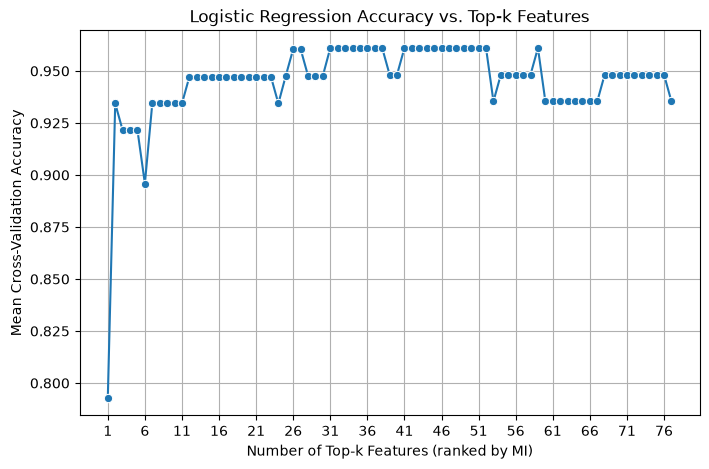


Best number of features: 31
Best cross-validation accuracy: 0.961

Selected features:
acc_z_std
acc_z_rms
acc_z_range
acc_z_min
acc_y_min
acc_magnitude_mean
acc_magnitude_rms
acc_y_range
acc_x_range
acc_y_std
acc_magnitude_std
acc_y_rms
acc_y_median
acc_magnitude_median
acc_z_max
acc_x_max
acc_y_max
acc_magnitude_range
acc_magnitude_max
acc_x_min
gyro_z_min
acc_x_std
acc_x_rms
gyro_y_min
grav_x_max
gyro_z_range
acc_y_mean
gyro_x_range
gyro_z_rms
gyro_z_std
gyro_x_min

Mutual Information ranking:


,feature,MI_score
15,acc_z_std,0.486460
20,acc_z_rms,0.466466
18,acc_z_range,0.465092
16,acc_z_min,0.429624
9,acc_y_min,0.426302
...,...,...
27,gyro_x_rms,0.000000
44,grav_x_min,0.000000
19,acc_z_median,0.000000
22,gyro_x_std,0.000000



Final test accuracy: 1.0

Confusion Matrix:
[[3 0]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

       bumpy       1.00      1.00      1.00         3
      smooth       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [436]:
# ============================================================
# FEATURE SELECTION WITH MUTUAL INFORMATION
# Adapted from the lab-session code
# ============================================================


# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# STEP 1: GROUP-AWARE CROSS-VALIDATION
# ============================================================

# We use the training recordings to choose the best
# number of features.
#
# Complete recordings stay together during validation.

cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Number of extracted features

total_features = X_train.shape[1]


# Store the mean validation accuracy for each value of k

accuracy_list = []


# ============================================================
# STEP 2: TRY DIFFERENT NUMBERS OF FEATURES
# ============================================================

for k in range(1, total_features + 1):

    fold_accuracies = []


    # --------------------------------------------------------
    # Cross-validation loop
    # --------------------------------------------------------

    for train_index, val_index in cv.split(
        X_train,
        y_train,
        groups=groups_train
    ):

        # Training part of this fold

        X_fold_train = X_train.iloc[train_index]
        y_fold_train = y_train.iloc[train_index]


        # Validation part of this fold

        X_fold_val = X_train.iloc[val_index]
        y_fold_val = y_train.iloc[val_index]


        # ----------------------------------------------------
        # Scale features
        # ----------------------------------------------------

        # Fit scaler ONLY on training fold

        scaler = StandardScaler()


        X_fold_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_fold_train),
            columns=X_fold_train.columns
        )


        # Use same scaler for validation fold

        X_fold_val_scaled = pd.DataFrame(
            scaler.transform(X_fold_val),
            columns=X_fold_val.columns
        )


        # ----------------------------------------------------
        # Compute Mutual Information scores
        # ----------------------------------------------------

        # MI uses ONLY the training fold

        mi_scores = mutual_info_classif(
            X_fold_train_scaled,
            y_fold_train,
            random_state=42
        )


        # Sort feature indices from highest MI to lowest

        feature_ranking = np.argsort(mi_scores)[::-1]


        # Select the best k features

        top_k_features = X_fold_train_scaled.columns[
            feature_ranking[:k]
        ]


        # ----------------------------------------------------
        # Train Logistic Regression
        # ----------------------------------------------------

        model = LogisticRegression(
            max_iter=5000,
            random_state=42
        )


        model.fit(
            X_fold_train_scaled[top_k_features],
            y_fold_train
        )


        # ----------------------------------------------------
        # Predict validation data
        # ----------------------------------------------------

        y_pred = model.predict(
            X_fold_val_scaled[top_k_features]
        )


        # Calculate validation accuracy

        fold_accuracy = accuracy_score(
            y_fold_val,
            y_pred
        )


        fold_accuracies.append(
            fold_accuracy
        )


    # --------------------------------------------------------
    # Mean accuracy across validation folds
    # --------------------------------------------------------

    mean_accuracy = np.mean(
        fold_accuracies
    )


    accuracy_list.append(
        mean_accuracy
    )



# ============================================================
# STEP 3: PLOT ACCURACY VS NUMBER OF FEATURES
# ============================================================

plt.figure(figsize=(8, 5))

sns.lineplot(
    x=range(1, total_features + 1),
    y=accuracy_list,
    marker="o"
)

plt.xlabel(
    "Number of Top-k Features (ranked by MI)"
)

plt.ylabel(
    "Mean Cross-Validation Accuracy"
)

plt.title(
    "Logistic Regression Accuracy vs. Top-k Features"
)

plt.xticks(
    range(
        1,
        total_features + 1,
        5
    )
)

plt.grid(True)

plt.show()



# ============================================================
# STEP 4: FIND THE BEST NUMBER OF FEATURES
# ============================================================

best_k = np.argmax(
    accuracy_list
) + 1


print(
    "\nBest number of features:",
    best_k
)

print(
    "Best cross-validation accuracy:",
    round(
        max(accuracy_list),
        3
    )
)



# ============================================================
# STEP 5: SCALE THE COMPLETE TRAINING DATA
# ============================================================

# Now that k has been selected,
# fit scaler on ALL training data.

scaler = StandardScaler()


X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)


# Transform final test data using the SAME scaler

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)



# ============================================================
# STEP 6: COMPUTE FINAL MUTUAL INFORMATION RANKING
# ============================================================

# Calculate MI scores using ALL training data

mi_scores = mutual_info_classif(
    X_train_scaled,
    y_train,
    random_state=42
)


# Rank features

feature_ranking = np.argsort(
    mi_scores
)[::-1]


# Select the best k features

top_k_features = X_train_scaled.columns[
    feature_ranking[:best_k]
]



# ------------------------------------------------------------
# Show selected features
# ------------------------------------------------------------

print("\nSelected features:")

for feature in top_k_features:
    print(feature)



# ------------------------------------------------------------
# Create MI ranking table
# ------------------------------------------------------------

mi_table = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "MI_score": mi_scores
})


mi_table = mi_table.sort_values(
    "MI_score",
    ascending=False
)


print("\nMutual Information ranking:")

display(mi_table)



# ============================================================
# STEP 7: TRAIN FINAL LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)


model.fit(
    X_train_scaled[top_k_features],
    y_train
)



# ============================================================
# STEP 8: FINAL TEST PREDICTION
# ============================================================

# The final test recordings are used for the first time here.

y_pred = model.predict(
    X_test_scaled[top_k_features]
)



# ============================================================
# STEP 9: FINAL TEST ACCURACY
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
    "\nFinal test accuracy:",
    round(
        test_accuracy,
        3
    )
)



# ============================================================
# STEP 10: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nConfusion Matrix:")

print(cm)



# ============================================================
# STEP 11: CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

### Feature subset for the initial clustering experiment

Take the specified number of features from the retained MI ranking. This is an exploratory choice, separate from the logistic-regression feature-count search.

In [437]:
selected_features = 7
top_selected_featues = top_k_features[:selected_features]
X_train_scaled[top_selected_featues]

,acc_z_std,acc_z_rms,acc_z_range,acc_z_min,acc_y_min,acc_magnitude_mean,acc_magnitude_rms
0,-0.023184,0.069216,-0.434694,0.024136,-0.090619,-0.031149,-0.099122
1,-0.120037,-0.055898,-0.532732,0.359485,0.201651,-0.037337,-0.107347
2,-0.121794,-0.020219,-0.324628,0.024658,0.201651,0.095847,0.023005
3,0.756506,0.792714,1.014314,-1.455453,-0.675176,0.663565,0.635945
4,0.784748,0.845077,1.131676,-1.998101,0.063023,0.586340,0.615042
...,...,...,...,...,...,...,...
72,-1.738662,-1.768637,-1.471769,1.425076,1.477849,-1.776245,-1.787014
73,-1.726330,-1.757054,-1.462469,1.425076,0.847827,-1.766209,-1.733587
74,-1.397613,-1.454010,-1.311322,1.344219,1.330054,-1.715240,-1.729255
75,-1.377293,-1.414802,-1.115382,1.231559,0.951575,-1.672479,-1.674500


## 7. Clustering experiments

These experiments use standardized, MI-ranked features. MI selection uses surface labels, so the overall pipeline is label-informed. The reported clustering agreement is measured on training windows and is not an independent test score.

### Hierarchical clustering

Build a linkage tree and divide it into two clusters. Use the dendrogram to inspect which windows group together.

#### Encode surface labels

Convert surface names to numerical labels for evaluation. Cluster IDs are arbitrary and must be matched to the surface labels.

In [438]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

#### Dendrogram display

Show a truncated overview and a full tree labelled with window IDs. The cut line illustrates the selected split.

In [439]:

# Plotting function
def plot_dendrogram(Z, window_labels, distance_threshold):
    # Create a figure with two subplots
    """Plot truncated and full linkage trees with window labels and a cut line."""
    fig, axs = plt.subplots(1, 2, figsize=(20, 8))

    # Plot the truncated dendrogram (top 3 levels)
    dendrogram(Z, 
               truncate_mode='level',  
               p=3,                    
               labels=window_labels,        
               leaf_rotation=90,        
               leaf_font_size=8,      
               ax=axs[0])              
    axs[0].axhline(y=distance_threshold, color='r', linestyle='--')
    axs[0].set_title("Dendrogram (Top 3 Levels)")
    axs[0].set_xlabel("Window ID or grouped window count")
    axs[0].set_ylabel("Distance")

    # Plot the full dendrogram (all levels)
    dendrogram(Z, 
               truncate_mode=None,  
               labels=window_labels,     
               leaf_rotation=90,     
               leaf_font_size=8,   
               ax=axs[1],           
               show_leaf_counts=False)  
    axs[1].axhline(y=distance_threshold, color='r', linestyle='--')
    axs[1].set_title("Dendrogram (Full)")
    axs[1].set_xlabel("Window ID")  
    axs[1].set_ylabel("Distance")

    # Set the main title for the entire figure
    plt.suptitle(f"Complete-linkage dendrograms - threshold = {distance_threshold:g}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



# Window IDs in the same row order used to compute Z.
window_labels = features_df.loc[X_train.index, "window_id"].tolist()



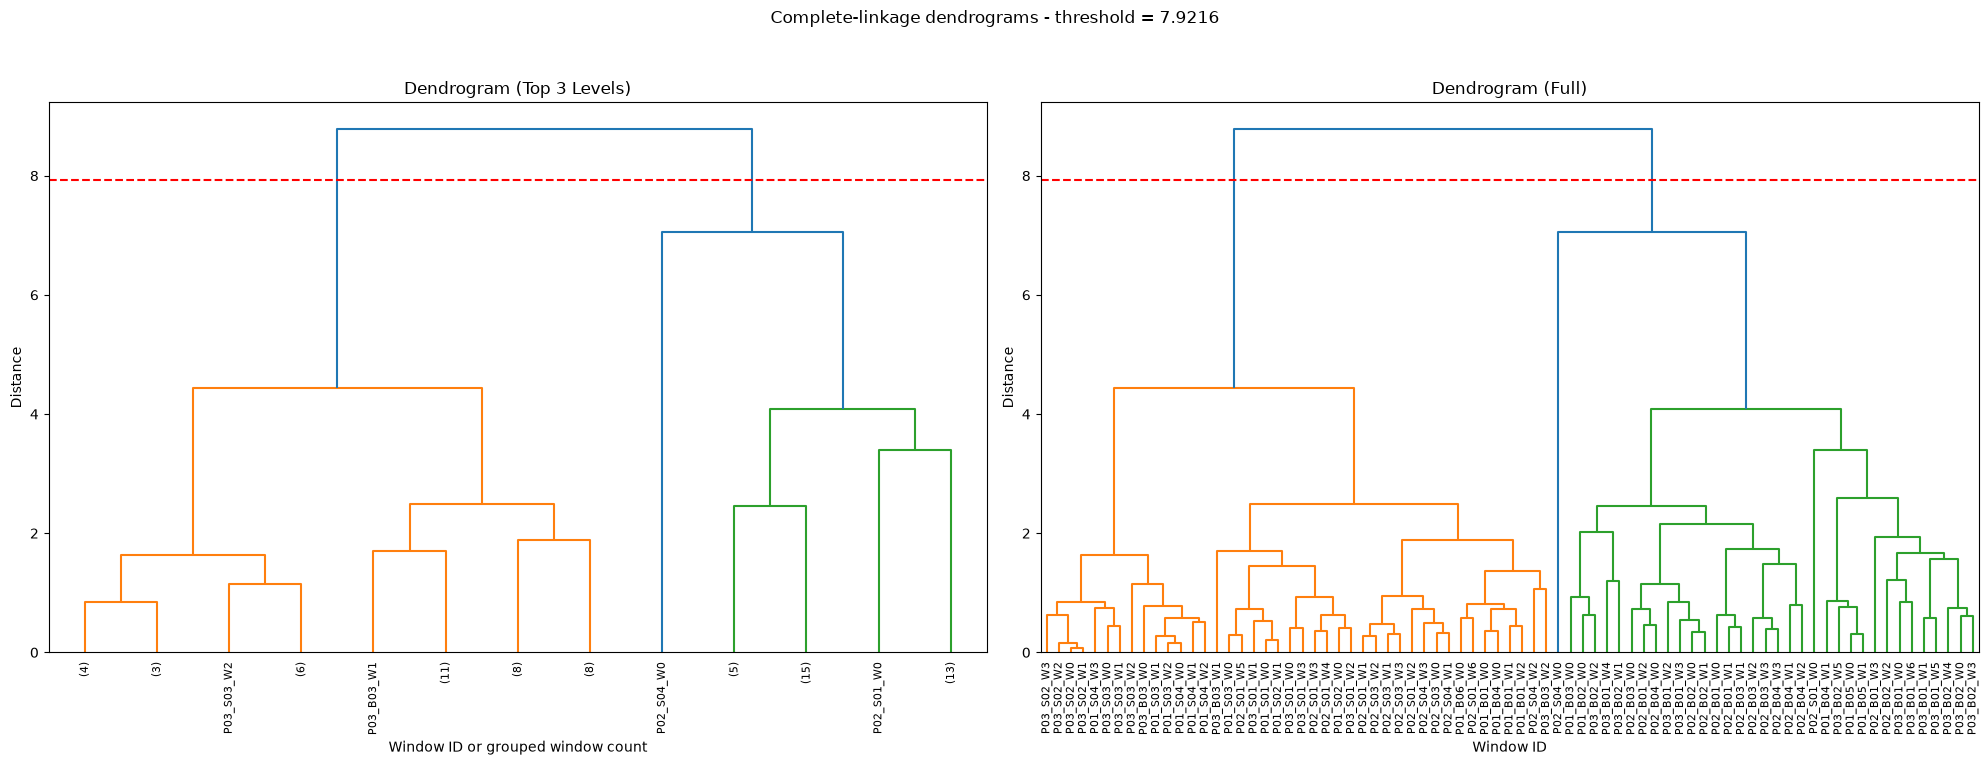

In [440]:
# write your Clustering function here
def perform_clustering(data, method="single"):
    """Fit the chosen linkage method and return two cluster assignments.

    Return the linkage matrix, cluster IDs, and a display cut height.
    Tied merge heights may prevent a horizontal line showing the split."""
    Z = linkage(data, method=method)

    # Explicitly create two clusters.
    clusters = cut_tree(Z, n_clusters=2).flatten()

    # Height used only to illustrate the split on the dendrogram.
    distance_threshold = (Z[-2, 2] + Z[-1, 2]) / 2

    if Z[-2, 2] == Z[-1, 2]:
        print("Tied merge heights: a horizontal line cannot show "
              "the exact two-cluster split.")

    return Z, clusters, distance_threshold


Z, clusters, distance_threshold = perform_clustering(
    X_train_scaled[top_selected_featues],
    method="complete"
)

window_labels = features_df.loc[
    X_train.index, "window_id"
].tolist()

plot_dendrogram(Z, window_labels, distance_threshold)




#### Training agreement

Compare both possible mappings between two cluster IDs and the encoded surface labels. Use the better mapping for training agreement and the confusion matrix. Do not use this mapping-selection function directly on held-out labels.

Training-window label-matched agreement: 87.0%


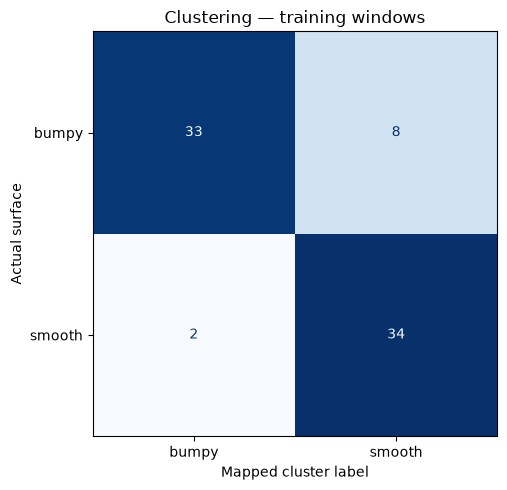

In [441]:
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_clustering(clusters, true_labels):
    """Evaluate two clusters against encoded binary labels on the same rows.

    Choose the better label permutation, plot its confusion matrix, and
    return agreement and mapped labels. Intended for training exploration;
    it chooses the mapping using the labels supplied to this function."""
    true_labels = np.asarray(true_labels)

    # Check both possible cluster-to-class mappings.
    accuracy_original = np.mean(clusters == true_labels)
    accuracy_swapped = np.mean((1 - clusters) == true_labels)

    if accuracy_swapped > accuracy_original:
        predicted_labels = 1 - clusters
    else:
        predicted_labels = clusters.copy()

    accuracy = np.mean(predicted_labels == true_labels)

    print(f"Training-window label-matched agreement: {accuracy:.1%}")

    # Use the SAME mapping for accuracy and the confusion matrix.
    cm = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=[0, 1]
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title("Clustering — training windows")
    ax.set_xlabel("Mapped cluster label")
    ax.set_ylabel("Actual surface")
    plt.tight_layout()
    plt.show()

    return accuracy, predicted_labels


clustering_accuracy, mapped_labels = evaluate_clustering(
    clusters,
    y_train_encoded
)

#### Hierarchical feature-count sweep

Compare training agreement across feature counts from the existing MI-ranked list. The best training score is an exploratory tuning result.

Best feature count: 4
Best training agreement: 92.2%


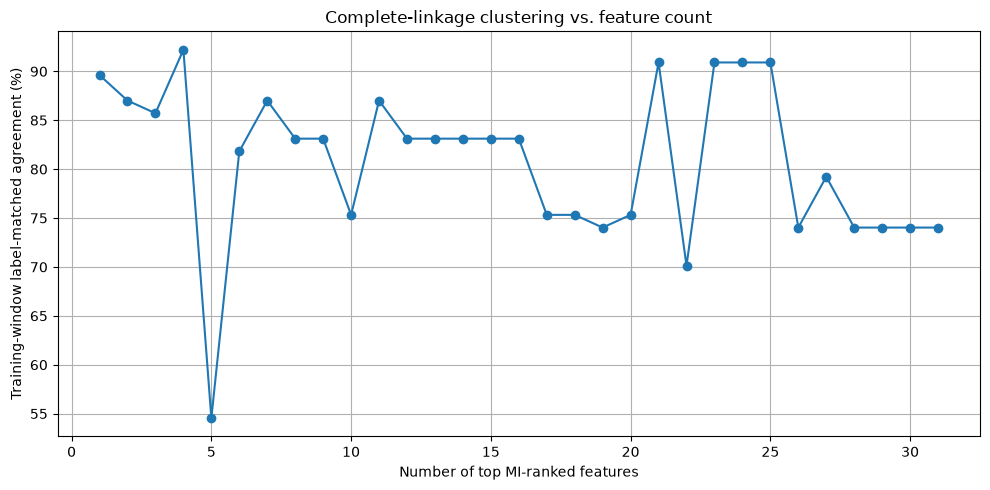

In [442]:
feature_counts = range(1, len(top_k_features) + 1)
clustering_accuracies = []

for k in feature_counts:
    selected_columns = top_k_features[:k]

    Z_k, clusters_k, threshold_k = perform_clustering(
        X_train_scaled[selected_columns],
        method="complete"
    )

    # Match the two cluster IDs to the two encoded classes.
    accuracy_original = np.mean(clusters_k == y_train_encoded)
    accuracy_swapped = np.mean((1 - clusters_k) == y_train_encoded)

    clustering_accuracies.append(
        max(accuracy_original, accuracy_swapped)
    )

# Select the smallest feature count achieving the highest score.
best_index = int(np.argmax(clustering_accuracies))
best_k_clustering = list(feature_counts)[best_index]

print(f"Best feature count: {best_k_clustering}")
print(
    f"Best training agreement: "
    f"{clustering_accuracies[best_index]:.1%}"
)

plt.figure(figsize=(10, 5))
plt.plot(
    list(feature_counts),
    np.array(clustering_accuracies) * 100,
    marker="o"
)
plt.xlabel("Number of top MI-ranked features")
plt.ylabel("Training-window label-matched agreement (%)")
plt.title("Complete-linkage clustering vs. feature count")
plt.grid(True)
plt.tight_layout()
plt.show()

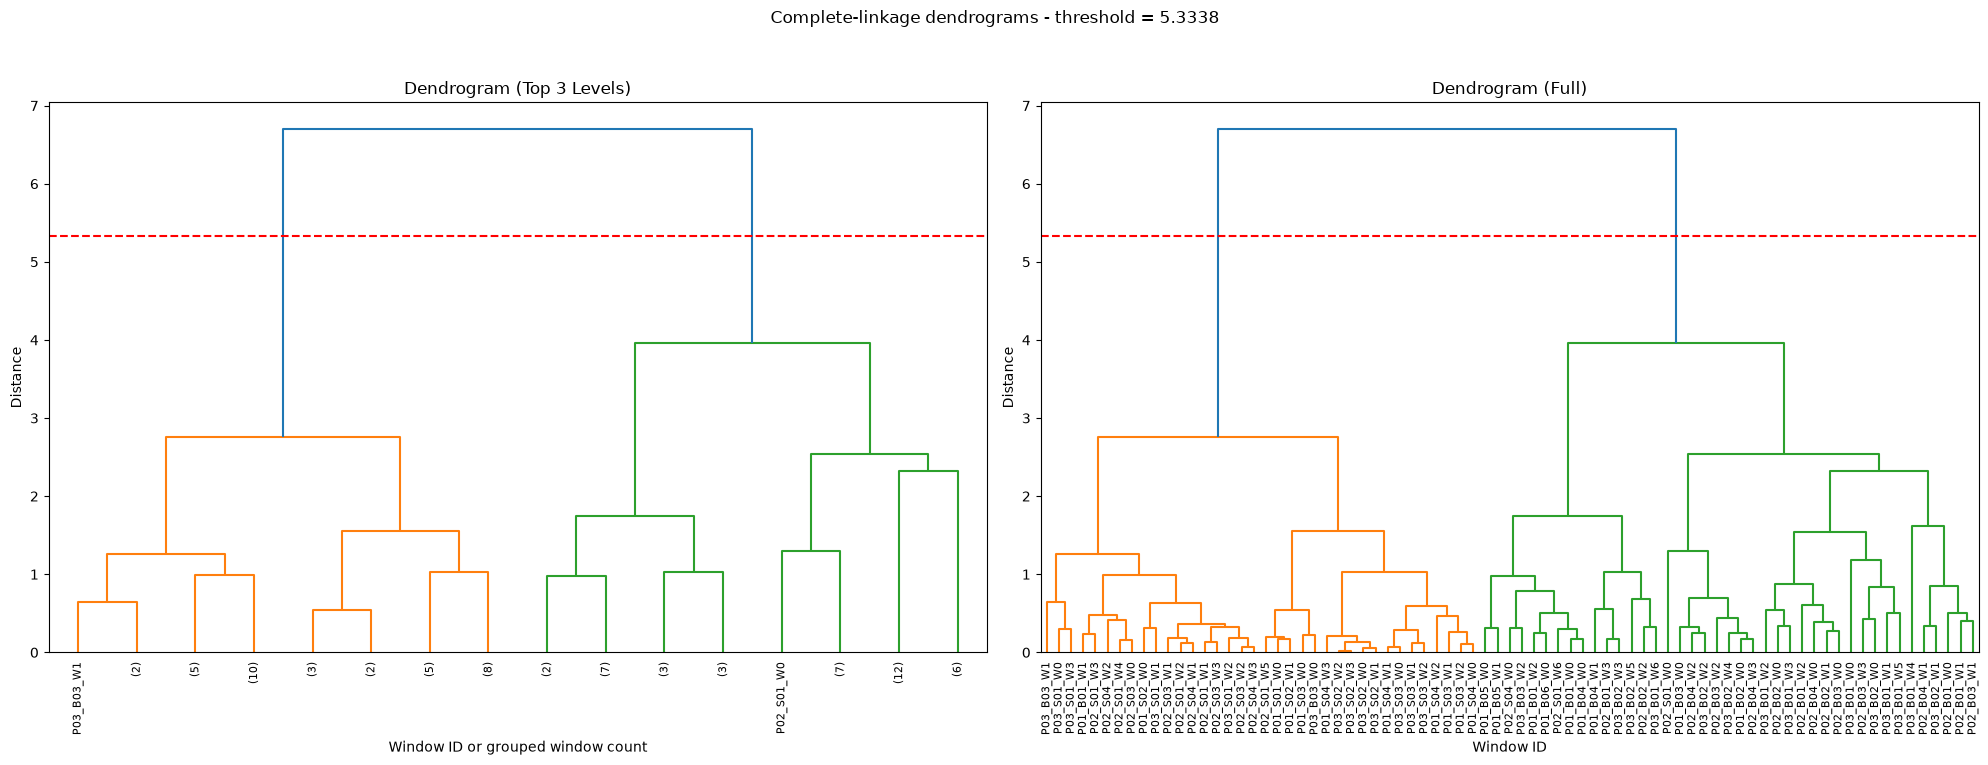

Training-window label-matched agreement: 92.2%


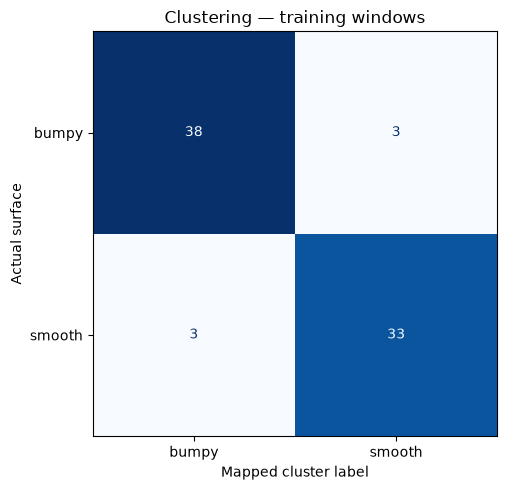

In [443]:
best_columns = top_k_features[:best_k_clustering]

Z_best, clusters_best, threshold_best = perform_clustering(
    X_train_scaled[best_columns],
    method="complete"
)

window_labels = features_df.loc[
    X_train.index, "window_id"
].tolist()

plot_dendrogram(Z_best, window_labels, threshold_best)

best_accuracy, mapped_labels = evaluate_clustering(
    clusters_best,
    y_train_encoded
)

### Gustafson–Kessel clustering

Fit fuzzy clusters and assign each window to the cluster with its highest membership. The feature sweep keeps two clusters and reports training agreement; invalid configurations are skipped.

#### Earlier cluster-count sweep

This earlier experiment varies the number of clusters. **Current code note:** `best_k_clustering` is a feature count, but this cell uses it as a column label in `X_train_scaled`. This may stop a fresh run. The cell is retained unchanged.

In [444]:
# Initialize lists to store results
cluster_range = range(2, 11)
partition_matrices = []
cluster_centers_list = []

X_train_scaled[
    top_k_features[:best_k_clustering]
].to_numpy(dtype=float)

# First loop: Perform clustering for each number of clusters
for n_clusters in cluster_range:
    # Perform clustering with the specified number of clusters
    cl = Clusterer(n_clusters, data=clustering_data, verbose=False)
    cluster_centers, partition_matrix, _ = cl.cluster(method="gk", error=1e-6)
    
    # Store the results
    partition_matrices.append(partition_matrix)
    cluster_centers_list.append(cluster_centers)
    
# return partition_matrices
# return cluster_centers

#### GK feature-count sweep

Keep two clusters and vary the number of MI-ranked features. Retain the fitted results so the chosen configuration can be plotted without refitting.

k=1, input shape=(77, 1)
k=2, input shape=(77, 2)
k=3, input shape=(77, 3)
k=4, input shape=(77, 4)
k=5, input shape=(77, 5)
k=6, input shape=(77, 6)
k=7, input shape=(77, 7)
k=8, input shape=(77, 8)
k=9, input shape=(77, 9)
Skipped 9 features: Hard assignments collapsed to one cluster.
k=10, input shape=(77, 10)
k=11, input shape=(77, 11)
k=12, input shape=(77, 12)
Skipped 12 features: Hard assignments collapsed to one cluster.
k=13, input shape=(77, 13)
Skipped 13 features: Hard assignments collapsed to one cluster.
k=14, input shape=(77, 14)
Skipped 14 features: Hard assignments collapsed to one cluster.
k=15, input shape=(77, 15)
Skipped 15 features: Hard assignments collapsed to one cluster.
k=16, input shape=(77, 16)
Skipped 16 features: Hard assignments collapsed to one cluster.
k=17, input shape=(77, 17)
Skipped 17 features: Hard assignments collapsed to one cluster.
k=18, input shape=(77, 18)
Skipped 18 features: Hard assignments collapsed to one cluster.
k=19, input shape=(77

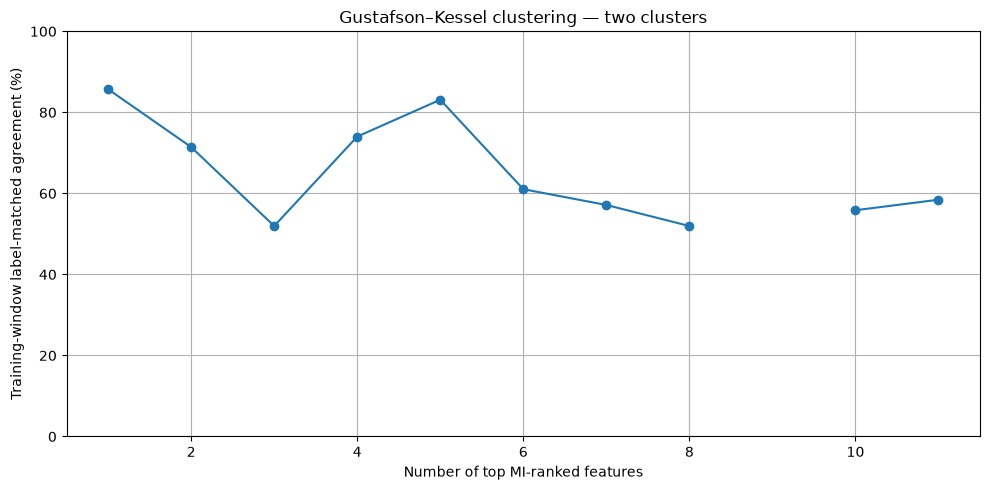

Best feature count: 1
Best training agreement: 85.7%
Training-window label-matched agreement: 85.7%


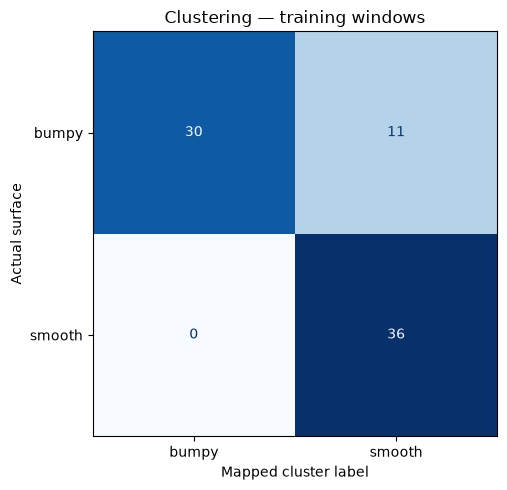

<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

In [445]:
accuracies = []
true_labels = np.asarray(y_train_encoded)

from pyfume.Clustering import Clusterer

true_labels = np.asarray(y_train_encoded)

# Sweep the existing MI-ranked feature list.
feature_counts = list(range(1, len(top_k_features) + 1))

gk_accuracies = []
gk_results = {}

for k in feature_counts:
    selected_columns = top_k_features[:k]

    clustering_data = X_train_scaled[
        selected_columns
    ].to_numpy(dtype=float)

    # Optional check: the number of columns should increase.
    print(f"k={k}, input shape={clustering_data.shape}")

    np.random.seed(42)

    # Keep the rest of your loop here unchanged.

    # Reproducible initialization for each feature count.
    np.random.seed(42)

    try:
        cl = Clusterer(
            2,
            data=clustering_data,
            verbose=False
        )

        centers, memberships, _ = cl.cluster(
            method="gk",
            error=1e-6
        )

        memberships = np.asarray(memberships)

        # Expected shape: one row per window, two columns.
        if memberships.shape != (len(true_labels), 2):
            raise ValueError(
                f"Unexpected membership shape: {memberships.shape}"
            )

        if not np.isfinite(memberships).all():
            raise ValueError("GK returned non-finite memberships.")

        assigned_clusters = np.argmax(memberships, axis=1)

        if len(np.unique(assigned_clusters)) != 2:
            raise ValueError("Hard assignments collapsed to one cluster.")

        # Match arbitrary cluster IDs to the encoded surface labels.
        accuracy_original = np.mean(
            assigned_clusters == true_labels
        )
        accuracy_swapped = np.mean(
            (1 - assigned_clusters) == true_labels
        )

        accuracy = max(accuracy_original, accuracy_swapped)

        gk_accuracies.append(accuracy)
        gk_results[k] = {
            "features": selected_columns,
            "centers": centers,
            "memberships": memberships,
            "clusters": assigned_clusters
        }

    except (np.linalg.LinAlgError, ValueError, FloatingPointError) as exc:
        # Keep failed configurations visible as gaps in the curve.
        gk_accuracies.append(np.nan)
        print(f"Skipped {k} features: {exc}")


# Plot the sweep.
plt.figure(figsize=(10, 5))

plt.plot(
    feature_counts,
    np.asarray(gk_accuracies) * 100,
    marker="o"
)

plt.xlabel("Number of top MI-ranked features")
plt.ylabel("Training-window label-matched agreement (%)")
plt.title("Gustafson–Kessel clustering — two clusters")
plt.ylim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


# Select the smallest feature count achieving the highest score.
if np.isfinite(gk_accuracies).any():
    best_index = int(np.nanargmax(gk_accuracies))
    best_k_gk = feature_counts[best_index]

    print(f"Best feature count: {best_k_gk}")
    print(
        f"Best training agreement: "
        f"{gk_accuracies[best_index]:.1%}"
    )

    # Reuse the stored result rather than rerunning randomized clustering.
    best_clusters_gk = gk_results[best_k_gk]["clusters"]

    # Uses your existing label-matching and confusion-matrix function.
    gk_accuracy, gk_mapped_labels = evaluate_clustering(
        best_clusters_gk,
        true_labels
    )
else:
    print("No valid GK configuration was produced.")
# Plotting the results
plt.figure(figsize=(18, 6))


#### Display the selected GK result

Compare hard cluster assignments with actual surfaces. A one-feature result is displayed on a horizontal line; otherwise the plot shows the first two selected features.

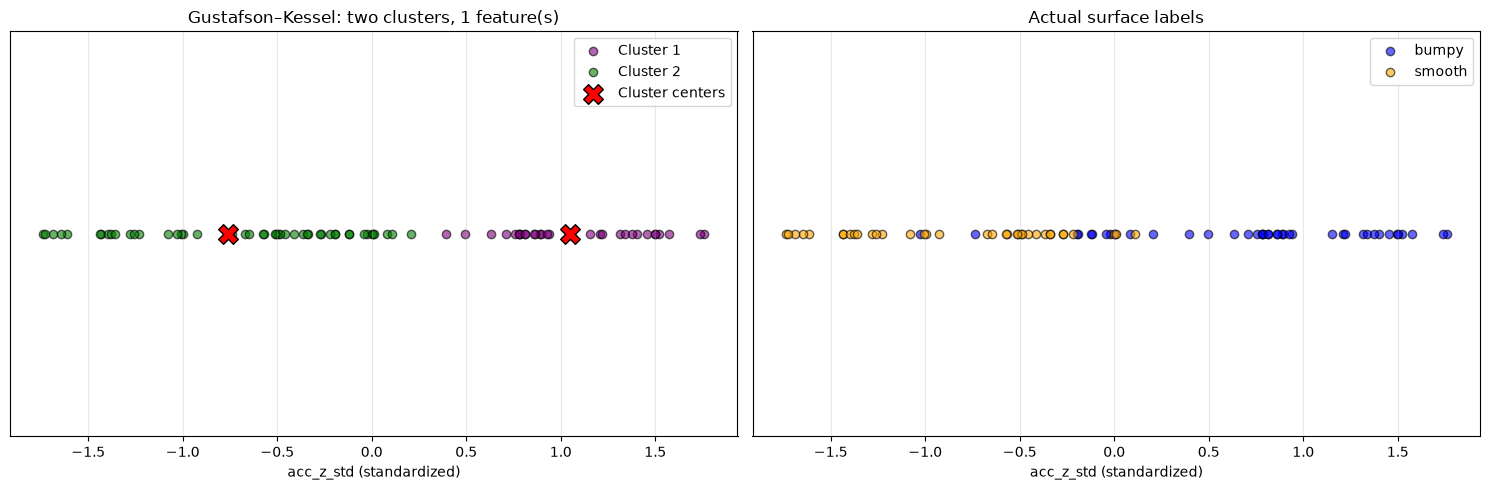

In [446]:
# Retrieve the best GK result from the feature sweep.
best_result = gk_results[best_k_gk]

selected_columns = best_result["features"]

clustering_data = X_train_scaled[
    selected_columns
].to_numpy(dtype=float)

cluster_centers = np.asarray(best_result["centers"])
partition_matrix = np.asarray(best_result["memberships"])

# Assign each window to its highest-membership cluster.
assigned_clusters = np.argmax(partition_matrix, axis=1)
true_labels = np.asarray(y_train_encoded)

# Plot the first two selected features when available.
x_values = clustering_data[:, 0]
center_x = cluster_centers[:, 0]

if clustering_data.shape[1] >= 2:
    y_values = clustering_data[:, 1]
    center_y = cluster_centers[:, 1]
    y_label = selected_columns[1] + " (standardized)"
else:
    # With one feature, display all points on a horizontal line.
    y_values = np.zeros(len(clustering_data))
    center_y = np.zeros(len(cluster_centers))
    y_label = ""

fig, axs = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

# ------------------------------------------------------------
# Plot 1: Gustafson–Kessel cluster assignments
# ------------------------------------------------------------
cluster_colors = ["purple", "green"]

for cluster in range(2):
    mask = assigned_clusters == cluster

    axs[0].scatter(
        x_values[mask],
        y_values[mask],
        color=cluster_colors[cluster],
        label=f"Cluster {cluster + 1}",
        edgecolor="k",
        alpha=0.6
    )

axs[0].scatter(
    center_x,
    center_y,
    marker="X",
    color="red",
    s=200,
    edgecolor="k",
    label="Cluster centers",
    zorder=3
)

axs[0].set_title(
    f"Gustafson–Kessel: two clusters, {best_k_gk} feature(s)"
)

# ------------------------------------------------------------
# Plot 2: Actual surface labels
# ------------------------------------------------------------
true_colors = ["blue", "orange"]

for label in np.unique(true_labels):
    mask = true_labels == label

    axs[1].scatter(
        x_values[mask],
        y_values[mask],
        color=true_colors[label],
        label=label_encoder.classes_[label],
        edgecolor="k",
        alpha=0.6
    )

axs[1].set_title("Actual surface labels")

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
for ax in axs:
    ax.set_xlabel(selected_columns[0] + " (standardized)")
    ax.set_ylabel(y_label)
    ax.legend()
    ax.grid(True, alpha=0.3)

    if clustering_data.shape[1] == 1:
        ax.set_yticks([])
        ax.set_ylim(-0.5, 0.5)

plt.tight_layout()
plt.show()

### Gaussian mixture model

Follow the expectation-maximization steps from Instruction 6: initialize parameters, calculate responsibilities, update parameters, and track log-likelihood. This is an unsupervised mixture model; surface labels are used to evaluate the resulting clusters.

In [447]:
from scipy.stats import multivariate_normal


def initialize_GMM(X, K):
    """Initialize Gaussian means with K-means, identity covariances, and weights."""
    X = np.asarray(X, dtype=float)
    N, D = X.shape

    # Initialize means using K-means.
    kmeans = KMeans(
        n_clusters=K,
        n_init=10,
        random_state=42
    )
    labels = kmeans.fit_predict(X)

    means = kmeans.cluster_centers_.copy()

    # One identity covariance matrix per component.
    covs = np.repeat(
        np.eye(D)[None, :, :],
        K,
        axis=0
    )

    # Initial mixture weights from cluster sizes.
    counts = np.bincount(labels, minlength=K)

    if np.any(counts == 0):
        raise ValueError("An initial cluster is empty.")

    rho = counts / N

    return means, covs, rho


def log_component_probabilities(X, means, covs, rho):
    """Log of mixture weight times Gaussian density."""
    X = np.asarray(X, dtype=float)
    K = len(rho)

    log_probs = np.empty((len(X), K))

    for k in range(K):
        log_probs[:, k] = (
            np.log(rho[k])
            + multivariate_normal.logpdf(
                X,
                mean=means[k],
                cov=covs[k]
            )
        )

    return log_probs


def expectation_step(X, means, covs, rho):
    """Return normalized component responsibilities for each sample."""
    log_probs = log_component_probabilities(
        X, means, covs, rho
    )

    # Subtract row maximum before exponentiating.
    # This avoids underflow without changing the normalized result.
    row_max = log_probs.max(axis=1, keepdims=True)
    probabilities = np.exp(log_probs - row_max)

    gamma = probabilities / probabilities.sum(
        axis=1, keepdims=True
    )

    return gamma


def maximization_step(X, gamma, reg_covar=1e-6):
    """Update means, covariances, and weights from responsibilities.

    Add reg_covar to covariance diagonals for numerical stability."""
    X = np.asarray(X, dtype=float)
    N, D = X.shape
    K = gamma.shape[1]

    # Effective number of samples in each component.
    Nk = gamma.sum(axis=0)

    if np.any(Nk <= 1e-10):
        raise ValueError("A GMM component has effectively collapsed.")

    means = (gamma.T @ X) / Nk[:, None]
    covs = np.empty((K, D, D))

    for k in range(K):
        differences = X - means[k]

        covs[k] = (
            (differences * gamma[:, k, None]).T
            @ differences
        ) / Nk[k]

        # Stabilize covariance inversion.
        covs[k] += reg_covar * np.eye(D)

    rho = Nk / N

    return means, covs, rho


def loglikelihood(X, means, covs, rho):
    """Return the total log-likelihood under the current mixture parameters."""
    log_probs = log_component_probabilities(
        X, means, covs, rho
    )

    row_max = log_probs.max(axis=1, keepdims=True)

    log_density = (
        row_max[:, 0]
        + np.log(
            np.exp(log_probs - row_max).sum(axis=1)
        )
    )

    return log_density.sum()


def GMM_modeling(X, K, nr_iterations):
    """Fit a K-component Gaussian mixture for a fixed number of EM iterations.

    Return means, covariances, weights, final responsibilities, and
    the log-likelihood history. X must contain finite numerical features."""
    X = np.asarray(X, dtype=float)

    if not np.isfinite(X).all():
        raise ValueError("Input contains missing or infinite values.")

    means, covs, rho = initialize_GMM(X, K)

    J = []

    for iteration in range(nr_iterations):
        gamma = expectation_step(X, means, covs, rho)

        means, covs, rho = maximization_step(X, gamma)

        J.append(loglikelihood(X, means, covs, rho))

    # Recalculate responsibilities using the final parameters.
    gamma = expectation_step(X, means, covs, rho)

    return means, covs, rho, gamma, np.asarray(J)

#### Fit GMM and inspect convergence

Fit two Gaussian components using the selected feature subset. Plot training log-likelihood across the fixed number of EM iterations.

Features: ['acc_z_std', 'acc_z_rms']
Mixture weights: [0.32203228 0.67796772]
Cluster sizes: [25 52]


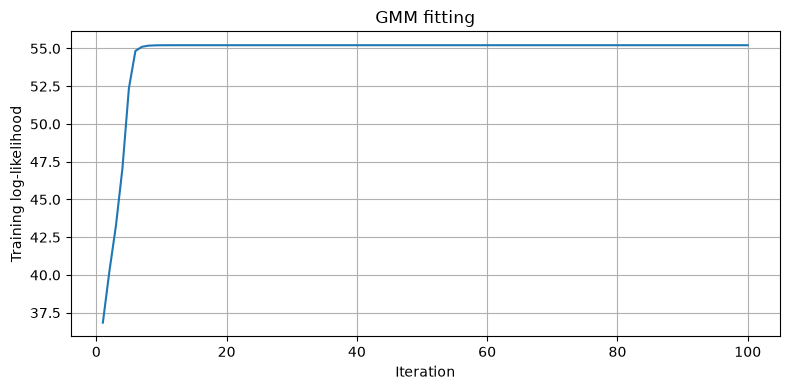

In [448]:
gmm_feature_count = 2
gmm_features = top_k_features[:gmm_feature_count]

X_gmm_train = X_train_scaled[
    gmm_features
].to_numpy(dtype=float)

means, covs, rho, gamma, J = GMM_modeling(
    X_gmm_train,
    K=2,
    nr_iterations=100
)

# Hard assignments from the highest responsibility.
gmm_clusters = np.argmax(gamma, axis=1)

print("Features:", list(gmm_features))
print("Mixture weights:", rho)
print("Cluster sizes:", np.bincount(gmm_clusters, minlength=2))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(J) + 1), J)
plt.xlabel("Iteration")
plt.ylabel("Training log-likelihood")
plt.title("GMM fitting")
plt.grid(True)
plt.tight_layout()
plt.show()

#### GMM assignments and surface labels

Compare component assignments with the known surfaces in the selected two-feature plane.

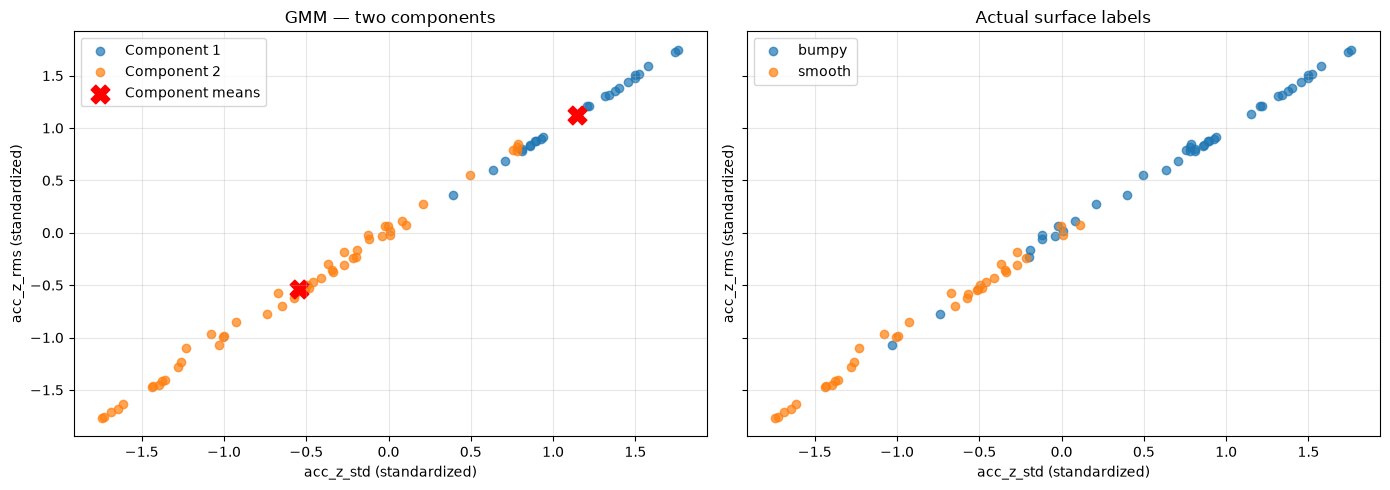

In [449]:
true_labels = np.asarray(y_train_encoded)

fig, axs = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharex=True,
    sharey=True
)

# GMM assignments.
for cluster in range(2):
    mask = gmm_clusters == cluster

    axs[0].scatter(
        X_gmm_train[mask, 0],
        X_gmm_train[mask, 1],
        label=f"Component {cluster + 1}",
        alpha=0.7
    )

axs[0].scatter(
    means[:, 0],
    means[:, 1],
    marker="X",
    color="red",
    s=180,
    label="Component means"
)

axs[0].set_title("GMM — two components")

# Actual surface labels.
for label in np.unique(true_labels):
    mask = true_labels == label

    axs[1].scatter(
        X_gmm_train[mask, 0],
        X_gmm_train[mask, 1],
        label=label_encoder.classes_[label],
        alpha=0.7
    )

axs[1].set_title("Actual surface labels")

for ax in axs:
    ax.set_xlabel(gmm_features[0] + " (standardized)")
    ax.set_ylabel(gmm_features[1] + " (standardized)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### GMM training agreement

Use the shared two-cluster evaluation function to calculate label-matched agreement and display a confusion matrix.

Training-window label-matched agreement: 79.2%


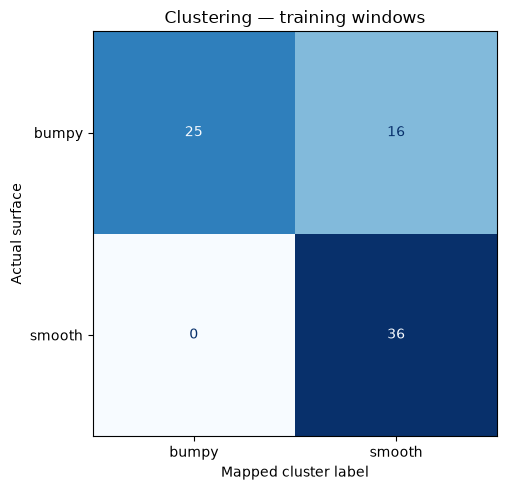

In [450]:
gmm_accuracy, gmm_mapped_labels = evaluate_clustering(
    gmm_clusters,
    y_train_encoded
)